In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thomaskonstantin/6000-children-and-teen-book-covers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '6000-children-and-teen-book-covers' dataset.
Path to dataset files: /kaggle/input/6000-children-and-teen-book-covers


## Data Importation

In [6]:
import pandas as pd
import os
from PIL import Image
import cv2
import numpy as np


In [7]:
path = kagglehub.dataset_download("thomaskonstantin/6000-children-and-teen-book-covers")
bookcovers_path = os.path.join(path,"BookCovers")
files = os.listdir(bookcovers_path)
for file in files:
  print(file)

Streaming output truncated to the last 5000 lines.
9780552570664-1-.jpg
9781843651635-1-.jpg
herecomesfrankie-.jpg
fiendish.jpg
norman-the-norman-from-normandy.jpg
little-truck.jpg
9780857560360-1-.jpg
the-clumsies-make-a-mess.jpg
kickoff.jpg
jack-s-fantastic-voyage.jpg
grandad-s-secret-giant.jpg
the-dogs.jpg
murder-most-unladylike.jpg
9781847802170.jpg
snail.jpg
lookingforalaska.jpg
sign-and-sing-along-series-incy-spider.jpg
mrs-mole.jpg
woozy-wizard-broom-togo-zoom.jpg
elmer.jpg
jill-and-lion.jpg
until-we-win.jpg
mctavish-on-the-move.jpg
who-let-the-gods-out.jpg
9780857532213-1-.jpg
for-every-one.jpg
varjak-paw.jpg
murder-on-the-safari-star.jpg
five-little-apples.jpg
my-big-barefoot-book-of-wonderful-words.jpg
rockoholic.jpg
malamander.jpg
the-wonderful-wizard-of-oz.jpg
the-wizards-of-once-twice-magic.jpg
action-rhymes.jpg
worldbetween.jpg
9781848771260-1-.jpg
red-rockets-and-rainbow-jelly.jpg
9781848691384.jpg
christmas-dinner-of-souls.jpg
9781407124063-1-.jpg
iguana-boy.jpg
dear-to

In [8]:
bookcovers_path = "/root/.cache/kagglehub/datasets/thomaskonstantin/6000-children-and-teen-book-covers/versions/1/BookCovers"

image_files = [f for f in os.listdir(bookcovers_path) if f.endswith('.jpg')]

df = pd.DataFrame({
    'image_filename': image_files,
    'image_path': [os.path.join(bookcovers_path, f) for f in image_files]
})

In [9]:
df.head(10)

,image_filename,image_path
0,the-rainmaker-danced.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
1,unlikely-hero-room13b.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
2,tiger.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
3,memoirs-of-a-neurotic-zombie2.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
4,9781842709870.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
5,the-baby.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
6,boy-and-the-globe.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
7,when-good-geeks-go-bad.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
8,sign-about-meal-time.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...
9,9781782955504.jpg,/root/.cache/kagglehub/datasets/thomaskonstant...


## EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6232 entries, 0 to 6231
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   image_filename  6232 non-null   object
 1   image_path      6232 non-null   object
dtypes: object(2)
memory usage: 97.5+ KB


In [11]:
df.isna().sum()/len(df)*100

,0
image_filename,0.0
image_path,0.0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# extract file
df['book_title'] = df['image_filename'].str.replace(r'\.jpg$','',regex=True)

In [14]:
# check images per book
class_distribution = df['book_title'].value_counts()
print(f"Total images   :{len(df)}")

Total images   :6232


In [15]:
print(f"\nTotal unique books: {class_distribution.shape[0]}")
print(f"Total images: {len(df)}")
print(f"Max images/book   : {class_distribution.max()}")
print(f"Min images/book   : {class_distribution.min()}")
print(f"Mean images/book  : {class_distribution.mean():.2f}")
print()



Total unique books: 6232
Total images: 6232
Max images/book   : 1
Min images/book   : 1
Mean images/book  : 1.00



In [16]:
print("Books by number of available covers:")
print(f"  3+ covers : {(class_distribution >= 3).sum()}")
print(f"  2 covers  : {((class_distribution >= 2) & (class_distribution < 3)).sum()}")
print(f"  1 cover   : {(class_distribution == 1).sum()}")

if (class_distribution == 1).all():
    print("\nEvery book has exactly 1 image.")
    print("   → Classification training is NOT viable (no examples to learn/validate with).")
    print("   → Use embedding/similarity retrieval instead, or get a multi-cover dataset.")

Books by number of available covers:
  3+ covers : 0
  2 covers  : 0
  1 cover   : 6232

Every book has exactly 1 image.
   → Classification training is NOT viable (no examples to learn/validate with).
   → Use embedding/similarity retrieval instead, or get a multi-cover dataset.


In [17]:
print([n for n in dir() if not n.startswith('_')])

['Image', 'In', 'Out', 'bookcovers_path', 'class_distribution', 'cv2', 'df', 'exit', 'file', 'files', 'get_ipython', 'image_files', 'kagglehub', 'np', 'os', 'path', 'pd', 'quit']


In [18]:
# checking for class imbalance
max_class = class_distribution.max()
min_class = class_distribution.min()
imbalanced_ratio = max_class/min_class
print(f"\nImbalanced_ratio: {imbalanced_ratio:.2f}x")


Imbalanced_ratio: 1.00x


In [19]:
#Trains an a book with more than three images
counts = df['book_title'].value_counts()
multi = counts[counts>=3].index
if len(multi) > 0:
  df_multi=df[df['book_title'].isin(keep)].reset_index(drop=True)
else:
  df_multi = df
  print(f"Books: {df_multi['book_title'].nunique()}, images: {len(df_multi)}")

Books: 6232, images: 6232


In [20]:
counts = df['book_title'].value_counts()
print("Books with 3+ covers:", (counts >= 3).sum())
print("Books with 2 covers :", (counts >= 2).sum())
print("Books with 1 cover  :", (counts == 1).sum())
print()
print(counts.head(10))

Books with 3+ covers: 0
Books with 2 covers : 0
Books with 1 cover  : 6232

book_title
deep-water                       1
the-rainmaker-danced             1
unlikely-hero-room13b            1
tiger                            1
memoirs-of-a-neurotic-zombie2    1
9781842709870                    1
the-baby                         1
boy-and-the-globe                1
when-good-geeks-go-bad           1
sign-about-meal-time             1
Name: count, dtype: int64


## Build Model

In [21]:
from sklearn.model_selection import train_test_split
X = df['image_path']
y = df["book_title"]

In [22]:
import tensorflow as tf
base = tf.keras.applications.ResNet50(
    include_top = False, pooling = 'avg',weights='imagenet'
)
inputs = tf.keras.Input(shape=(224,224,3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
outputs = base(x)
model = tf.keras.Model(inputs,outputs,name = 'cover_embedding_model')
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "cover_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [23]:
import os
print(os.path.isdir('/kaggle/working'))   # False for you
print(os.getcwd())                        # your real working directory

False
/content


In [24]:
def image_load(image_path):
  img = Image.open(image_path).convert('RGB')
  img = img.resize((224,224))
  img = np.array(img,dtype=np.uint8)
  return np.array(img,dtype=np.uint8)

In [25]:
import numpy as np
import tensorflow as tf
from PIL import Image

assert len(df) > 0, "df is empty! Re-run data loading cells from the top."
print(f"df loaded: {len(df)} covers, {df['book_title'].nunique()} unique books")

df loaded: 6232 covers, 6232 unique books


In [26]:
base = tf.keras.applications.ResNet50(include_top=False, pooling="avg", weights="imagenet")
inputs  = tf.keras.Input(shape=(224, 224, 3))
x= tf.keras.applications.resnet50.preprocess_input(inputs)
outputs = base(x)
model = tf.keras.Model(inputs, outputs, name="cover_embedding_model")
print("Model created:", model.name)


Model created: cover_embedding_model


In [27]:
def load_image(path):
  img = Image.open(path).convert("RGB").resize((224,224))
  return np.array(img,dtype = np.float32)

In [28]:
## Embedding
paths = df["image_path"].tolist()
print(f"Embedding {len(paths)} covers...")

all_embeddings = []
BATCH = 64
for i in range(0, len(paths), BATCH):
    batch = np.stack([load_image(p) for p in paths[i:i + BATCH]])
    embs = model.predict(batch, verbose=0)
    all_embeddings.append(embs)
    if (i // BATCH) % 10 == 0:
        print(f"  progress: {i + len(batch)}/{len(paths)}")

Embedding 6232 covers...
  progress: 64/6232
  progress: 704/6232
  progress: 1344/6232
  progress: 1984/6232
  progress: 2624/6232
  progress: 3264/6232
  progress: 3904/6232
  progress: 4544/6232
  progress: 5184/6232
  progress: 5824/6232


In [29]:
all_embeddings = np.vstack(all_embeddings).astype("float32")
print("Embeddings shape:",all_embeddings.shape)

Embeddings shape: (6232, 2048)


In [30]:
## Normalization
norms = np.linalg.norm(all_embeddings,axis = 1, keepdims=True)
embeddings_norm = all_embeddings / norms

In [31]:
## Save Artifacts
out_dir = "/kaggle/working" if os.path.isdir("/kaggle/working") else "/content/output"
os.makedirs(out_dir,exist_ok=True)

In [32]:
np.save(os.path.join(out_dir,"cover_embedding.npy"),embeddings_norm)
df[["book_title","image_path"]].to_csv(os.path.join(out_dir,"class_map.csv"),index=False)
model.save(os.path.join(out_dir,"book_cover_model.keras"))
print("Saved to:",out_dir)
print(" - cover-embedding.npy")
print(" - class_map.csv")
print(" - book_cover_model.keras")

Saved to: /content/output
 - cover-embedding.npy
 - class_map.csv
 - book_cover_model.keras


In [36]:
import matplotlib.pyplot as plt
scores = embeddings_norm @ embeddings_norm[0]
top5 = np.argsort(scores)[::-1][1:6]
print("Query book",df["book_title"].iloc[0])
print("Top-5 most similar covers:")
for rank, idx in enumerate(top5,1):
  print(f"{rank}.{df['book_title'].iloc[idx]}(similarity:{scores[idx]:.3f})")

Query book the-rainmaker-danced
Top-5 most similar covers:
1.my-mums-growing-down(similarity:0.862)
2.anisha-accidental-detective-schools-cancelled(similarity:0.854)
3.charlie-changes-into-a-chicken(similarity:0.853)
4.9780192745460-1-(similarity:0.850)
5.amazing-true-stories-about-animals-behaving-badly(similarity:0.848)


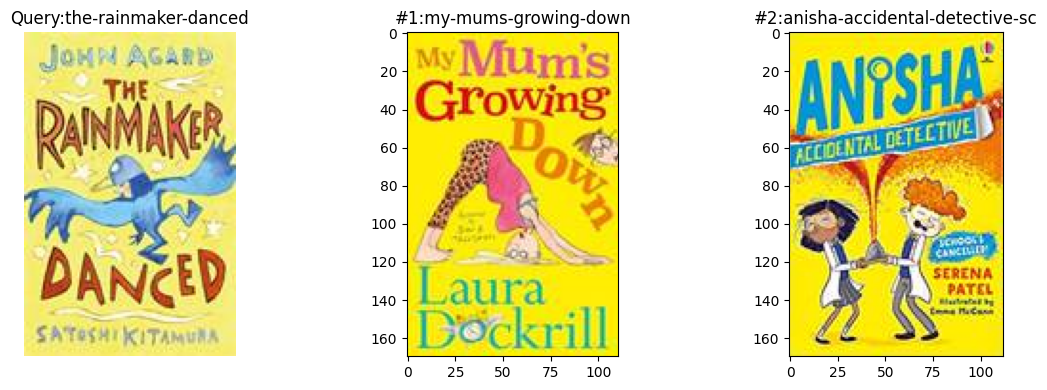

Done - Next: copy /content/output to Google Drive, then evaluate top 5 retrieval accuracy


<Figure size 640x480 with 0 Axes>

Done - Next: copy /content/output to Google Drive, then evaluate top 5 retrieval accuracy


<Figure size 640x480 with 0 Axes>

Done - Next: copy /content/output to Google Drive, then evaluate top 5 retrieval accuracy


In [34]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
axes[0].imshow(Image.open(paths[0]).convert("RGB"))
axes[0].set_title("Query:" + df ["book_title"].iloc[0][:30])
axes[1].imshow(Image.open(paths[top5[0]]).convert("RGB"))
axes[1].set_title(f"#1:{df["book_title"].iloc[top5[0]][:30]}")
axes[2].imshow(Image.open(paths[top5[1]]).convert("RGB"))
axes[2].set_title(f"#2:{df['book_title'].iloc[top5[1]][:30]}")

for ax in axes:
  ax.axis("off")
  plt.tight_layout()
  plt.show()
  print("Done - Next: copy /content/output to Google Drive, then evaluate top 5 retrieval accuracy")